# Diabetic Retinopathy Classification
## Fixed & Improved Version

### Bugs fixed:
1. Double normalization removed
2. `train_data`/`val_data` now properly created from generator
3. `class_weights` computed correctly from actual label array
4. Label ordering made consistent (manual load matches folder names)
5. EfficientNetB0 preprocessing done correctly
6. Learning rate scheduler added
7. ReduceLROnPlateau added for stable training

In [1]:
# ── Cell 1: Load CSV ──────────────────────────────────────────────────────────
import pandas as pd

df = pd.read_csv("data/train.csv")
print("Total samples:", len(df))
df.head()

Total samples: 3662


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [2]:
# ── Cell 2: Load Images (NO manual normalization — let EfficientNet handle it) ─
import os
import cv2
import numpy as np

base_dir = "F:/DR_Project/data/train_images/"

# ✅ IMPORTANT: Must match alphabetical order that ImageDataGenerator uses
#    Mild=0, Moderate=1, No_DR=2, Proliferate_DR=3, Severe=4
classes = ["Mild", "Moderate", "No_DR", "Proliferate_DR", "Severe"]

images = []
labels = []

for label, class_name in enumerate(classes):
    class_path = os.path.join(base_dir, class_name)
    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        # ✅ Do NOT divide by 255 here — EfficientNetB0 does its own preprocessing
        images.append(img)
        labels.append(label)

images = np.array(images, dtype=np.float32)  # float32 but still [0, 255]
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (3663, 224, 224, 3)
Labels shape: (3663,)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

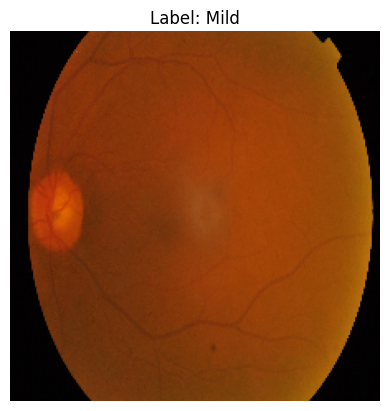

In [3]:
# ── Cell 3: Visualize a sample ────────────────────────────────────────────────
import matplotlib.pyplot as plt

class_names = ["Mild", "Moderate", "No_DR", "Proliferate_DR", "Severe"]
plt.imshow(images[0].astype(np.uint8))
plt.title(f"Label: {class_names[labels[0]]}")
plt.axis('off')

In [4]:
# ── Cell 4: Shuffle & Stratified Train/Val Split ──────────────────────────────
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

images, labels = shuffle(images, labels, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Val size:  ", X_val.shape[0])

Train size: 2930
Val size:   733


In [5]:
# ── Cell 5: Class Distribution & Weights ─────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

print("Class distribution (train):")
print(np.bincount(y_train))

# ✅ Compute class weights from y_train (not from train_data.classes)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_arr))
print("Class Weights:", class_weights)

Class distribution (train):
[ 296  800 1444  236  154]
Class Weights: {0: np.float64(1.9797297297297298), 1: np.float64(0.7325), 2: np.float64(0.40581717451523547), 3: np.float64(2.483050847457627), 4: np.float64(3.8051948051948052)}


In [6]:
# ── Cell 6: Data Augmentation with ImageDataGenerator ────────────────────────
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ✅ No rescale here! Images are already [0,255] float32
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# No augmentation for validation
val_datagen = ImageDataGenerator()

BATCH_SIZE = 32

train_gen = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train generator ready:", len(train_gen), "batches")
print("Val generator ready:  ", len(val_gen), "batches")

Train generator ready: 92 batches
Val generator ready:   23 batches


In [7]:
# ── Cell 7: Focal Loss ────────────────────────────────────────────────────────
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=5)
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * tf.pow(1.0 - y_pred, gamma)
        focal = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(focal, axis=1))
    return loss

In [8]:
# ── Cell 8: Build Model ───────────────────────────────────────────────────────
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.applications.efficientnet import preprocess_input

# ✅ EfficientNetB0 has its own preprocess_input built in when using
#    include_preprocessing=True (default in newer TF versions)
#    So raw [0,255] images are fine.

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all first
base_model.trainable = False

# Unfreeze last 30 layers for fine-tuning
for layer in base_model.layers[-30:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

# Build head
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  # training=False keeps BN frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,416,168 (16.85 MB)

 Trainable params: 1,847,397 (7.05 MB)

 Non-trainable params: 2,568,771 (9.80 MB)

In [9]:
# ── Cell 9: Compile ───────────────────────────────────────────────────────────
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

In [10]:
# ── Cell 10: Callbacks ────────────────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,          # ✅ Give more patience (was 3)
    restore_best_weights=True,
    verbose=1
)

# ✅ NEW: Reduce LR when val_accuracy plateaus — prevents the sudden drops
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# ✅ NEW: Save best model automatically
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [ ]:
# ── Cell 11: Train ────────────────────────────────────────────────────────────
history = model.fit(
    train_gen,                    # ✅ Use the correct generator (not train_data)
    epochs=30,
    validation_data=val_gen,      # ✅ Use the correct val generator
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights    # ✅ Computed from y_train
)

Epoch 1/30


In [ ]:
# ── Cell 12: Plot Training History ───────────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [ ]:
# ── Cell 13: Evaluate on Validation Set ──────────────────────────────────────
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
import seaborn as sns

# Get predictions
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=== Classification Report ===")
print(classification_report(y_val, y_pred, target_names=class_names))

kappa = cohen_kappa_score(y_val, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa: {kappa:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 14: (Optional) Phase 2 — Fine-tune full model at lower LR ───────────
# Unfreeze all layers and train with a much smaller learning rate

print("Starting Phase 2: Full fine-tuning...")

base_model.trainable = True

# Keep BatchNorm layers frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Much lower LR for fine-tuning
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)